In [1]:
import os
import numpy as np
import soundfile as sf
from tqdm import tqdm

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
JAZZ_PATH = os.path.join(BASE_PATH, "genres_stems", "jazz")

durations = []

for song_folder in tqdm(os.listdir(JAZZ_PATH)):
    song_path = os.path.join(JAZZ_PATH, song_folder)
    
    if os.path.isdir(song_path):
        for stem_file in ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]:
            stem_path = os.path.join(song_path, stem_file)
            
            if os.path.exists(stem_path):
                try:
                    f = sf.SoundFile(stem_path)
                    duration = len(f) / f.samplerate
                    durations.append(duration)
                except Exception as e:
                    print("Error:", stem_path, e)

mean_duration = np.mean(durations)

print("Total stems counted:", len(durations))
print("Mean duration (seconds):", mean_duration)

100%|██████████| 100/100 [00:02<00:00, 34.72it/s]

Total stems counted: 400
Mean duration (seconds): 30.032979591836728


In [2]:
import os
import soundfile as sf

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

audio_extensions = (".wav", ".flac", ".ogg", ".mp3")

sample_rates = set()

for root, dirs, files in os.walk(BASE_PATH):
    if files:
        for file in files:
            if file.lower().endswith(audio_extensions):
                file_path = os.path.join(root, file)
                try:
                    f = sf.SoundFile(file_path)
                    sample_rates.add(f.samplerate)
                except Exception as e:
                    print("Error:", file_path, e)

unique_rates = sorted(sample_rates)
print(unique_rates)

[22050, 44100]


In [3]:
import os
import soundfile as sf
from tqdm import tqdm

TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

audio_extensions = (".wav", ".flac", ".ogg", ".mp3")

zero_byte_count = 0
corrupted_count = 0
total_files = 0

for genre in tqdm(os.listdir(TRAIN_PATH)):
    genre_path = os.path.join(TRAIN_PATH, genre)
    
    if not os.path.isdir(genre_path):
        continue
    
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        
        if not os.path.isdir(song_path):
            continue
        
        for file in os.listdir(song_path):
            if file.lower().endswith(audio_extensions):
                total_files += 1
                file_path = os.path.join(song_path, file)
                
                # Zero byte check
                if os.path.getsize(file_path) == 0:
                    zero_byte_count += 1
                    continue
                
                # Corruption check
                try:
                    _ = sf.SoundFile(file_path)
                except Exception:
                    corrupted_count += 1

print("Total audio files:", total_files)
print("Zero-byte files:", zero_byte_count)
print("Corrupted files:", corrupted_count)
print("Total problematic:", zero_byte_count + corrupted_count)

100%|██████████| 10/10 [00:06<00:00,  1.60it/s]

Total audio files: 4000
Zero-byte files: 0
Corrupted files: 0
Total problematic: 0


In [4]:
import os
import numpy as np
import soundfile as sf
from tqdm import tqdm

TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

peak_db_values = []

for genre in tqdm(os.listdir(TRAIN_PATH)):
    genre_path = os.path.join(TRAIN_PATH, genre)
    
    if not os.path.isdir(genre_path):
        continue
    
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        
        if not os.path.isdir(song_path):
            continue
        
        vocals_path = os.path.join(song_path, "vocals.wav")
        
        if os.path.exists(vocals_path):
            try:
                audio, sr = sf.read(vocals_path)
                
                peak = np.max(np.abs(audio))
                
                if peak > 0:
                    peak_db = 20 * np.log10(peak)
                    peak_db_values.append(peak_db)
                    
            except Exception as e:
                print("Error:", vocals_path, e)

average_peak_db = np.mean(peak_db_values)

print("Total vocals files:", len(peak_db_values))
print("Average peak amplitude (dB):", average_peak_db)

100%|██████████| 10/10 [01:12<00:00,  7.27s/it]

Total vocals files: 1000
Average peak amplitude (dB): -12.478583504256113


In [6]:

import os
import numpy as np
import librosa
from tqdm import tqdm

TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues"

centroids_all = []

for song_folder in tqdm(os.listdir(TRAIN_PATH)):
    song_path = os.path.join(TRAIN_PATH, song_folder)
    
    if not os.path.isdir(song_path):
        continue
    
    for stem_file in ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]:
        file_path = os.path.join(song_path, stem_file)
        
        if os.path.exists(file_path):
            try:
                y, sr = librosa.load(file_path, sr=None)
                
                spectral_centroid = librosa.feature.spectral_centroid(
                    y=y,
                    sr=sr
                )
                
                centroids_all.extend(spectral_centroid.flatten())
                
            except Exception as e:
                print("Error:", file_path, e)

mean_centroid = np.mean(centroids_all)

print("Total frames:", len(centroids_all))
print("Mean spectral centroid (Hz) for Blues:", mean_centroid)

100%|██████████| 100/100 [00:59<00:00,  1.68it/s]

Total frames: 1034400
Mean spectral centroid (Hz) for Blues: 2296.782737115086


In [7]:
import os
import numpy as np
import librosa
from tqdm import tqdm

TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

genre_centroids = {}

stems = ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]

for genre in tqdm(os.listdir(TRAIN_PATH)):
    genre_path = os.path.join(TRAIN_PATH, genre)
    
    if not os.path.isdir(genre_path):
        continue
    
    centroids = []
    
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        
        if not os.path.isdir(song_path):
            continue
        
        for stem in stems:
            file_path = os.path.join(song_path, stem)
            
            if os.path.exists(file_path):
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    c = librosa.feature.spectral_centroid(y=y, sr=sr)
                    centroids.append(np.mean(c))
                except Exception as e:
                    print("Error:", file_path, e)
    
    if centroids:
        genre_centroids[genre] = np.mean(centroids)

# Find genre with highest centroid
highest_genre = max(genre_centroids, key=genre_centroids.get)

print("Mean spectral centroid per genre:")
for g, v in genre_centroids.items():
    print(g, ":", v)

print("\nGenre with highest mean spectral centroid:", highest_genre)

100%|██████████| 10/10 [14:15<00:00, 85.59s/it]

Mean spectral centroid per genre:
disco : 2454.1533850826813
metal : 2579.3243146551536
reggae : 2404.568992703987
blues : 2296.782737115086
rock : 2250.0843332686527
classical : 1674.7903261564497
jazz : 2544.1149574413557
hiphop : 2370.789957346027
country : 2266.7210020485495
pop : 2440.884880560034

Genre with highest mean spectral centroid: metal


In [10]:
import os
import numpy as np
import soundfile as sf
from tqdm import tqdm

TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

stems = ["bass.wav", "drums.wav", "other.wav", "vocals.wav"]

silence_threshold = 1e-6

silent_files_count = 0
total_files_checked = 0

for genre in tqdm(os.listdir(TRAIN_PATH)):
    genre_path = os.path.join(TRAIN_PATH, genre)
    
    if not os.path.isdir(genre_path):
        continue
    
    for song_folder in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song_folder)
        
        if not os.path.isdir(song_path):
            continue
        
        for stem in stems:
            file_path = os.path.join(song_path, stem)
            
            if os.path.exists(file_path):
                try:
                    audio, sr = sf.read(file_path)
                    
                    samples_05s = int(0.5 * sr)
                    first_segment = audio[:samples_05s]
                    
                    total_files_checked += 1
                    
                    if np.max(np.abs(first_segment)) <= silence_threshold:
                        silent_files_count += 1
                        
                except Exception as e:
                    print("Error:", file_path, e)

print("Total files checked:", total_files_checked)
print("Files with silence in first 0.5s:", silent_files_count)

100%|██████████| 10/10 [02:04<00:00, 12.49s/it]

Total files checked: 4000
Files with silence in first 0.5s: 126


/tmp/ipykernel_55/2789560866.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



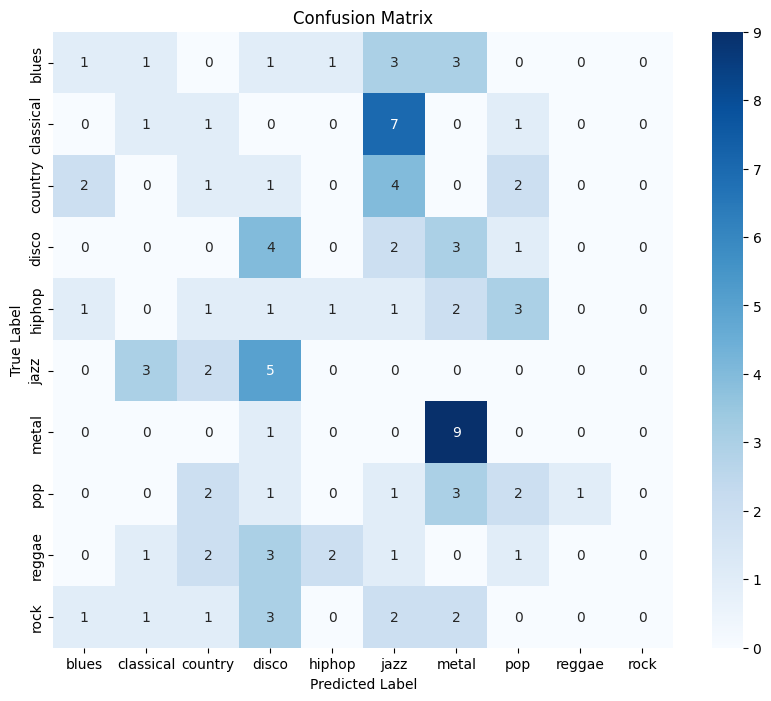


TP/TN/FP/FN per genre:
       Genre  TP  TN  FP  FN
0      blues   1  86   4   9
1  classical   1  84   6   9
2    country   1  81   9   9
3      disco   4  74  16   6
4     hiphop   1  87   3   9
5       jazz   0  69  21  10
6      metal   9  77  13   1
7        pop   2  82   8   8
8     reggae   0  89   1  10
9       rock   0  90   0  10


In [11]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


metrics = []

total = np.sum(cm)

for i, genre in enumerate(GENRES):
    
    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = total - (TP + FP + FN)
    
    metrics.append({
        "Genre": genre,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN
    })

metrics_df = pd.DataFrame(metrics)

print("\nTP/TN/FP/FN per genre:")
print(metrics_df)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy_score(y_val,y_pred)

0.19